# Sector Vulnerability-Proxy Modelling

This notebook trains **Random Forest** and **CatBoost** classifiers to approximate the census-informed sector vulnerability proxy from aggregated Sentinel-2 features.

**Scope:** This remains a 50-sector pilot even when using the x10 sector-subunit feature table. The x10 table gives the models more Sentinel texture, but the independent labels are still the 50 sectors. District-held-out validation is used throughout so performance is not inflated by testing on districts seen in training.

In [1]:
%matplotlib inline

from pathlib import Path
import importlib
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
if not (PROJECT_ROOT / 'scripts').exists():
    raise RuntimeError(f'Run this notebook from the repository root or notebooks directory: {PROJECT_ROOT}')

SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import train_sector_proxy_models as workflow
workflow = importlib.reload(workflow)

FEATURES_PATH = PROJECT_ROOT / 'data' / 'processed' / 'sector_subunit_x10_dataset.csv'
LABELS_PATH = PROJECT_ROOT / 'data' / 'labels' / 'sector_vulnerability_proxy_labels.csv'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'model_outputs'
MODEL_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Feature table: {FEATURES_PATH}')
print(f'Label table: {LABELS_PATH}')


Project root: /Users/kellia.umuhire/Documents/capstone
Feature table: /Users/kellia.umuhire/Documents/capstone/data/processed/sector_subunit_x10_dataset.csv
Label table: /Users/kellia.umuhire/Documents/capstone/data/labels/sector_vulnerability_proxy_labels.csv


## 1. Load the training data

The feature table can be either the original one-row-per-sector table or the x10 sector-subunit table. The label is the reviewed `proxy_class`. The selected Sentinel-2 features are means and standard deviations for elevation, NDVI, NDBI, MNDWI, and slope. Census variables that constructed the proxy label, coordinates, and raw observation counts are excluded to avoid leakage.

In [2]:
data, selected_features = workflow.load_training_data(FEATURES_PATH, LABELS_PATH)
metadata_columns = workflow.model_metadata_columns(data)
training_unit = workflow.training_unit(data)
training_view = data[[*metadata_columns, *selected_features]].copy()

print(f'Training unit: {training_unit}')
print(f'Training rows: {len(training_view)}')
print(f'Independent labelled sectors: {data["sector_id"].nunique()}')
print(f'Selected Sentinel features: {len(selected_features)}')
display(training_view.head())

Training unit: sector_subunit
Training rows: 500
Independent labelled sectors: 50
Selected Sentinel features: 10


,sector_subunit_id,sector_subunit_index,sentinel__subunit_matched_row_count,sector_id,sector_name,district,proxy_class,proxy_score,proxy_rank,sentinel__elevation__subunit_mean,sentinel__elevation__subunit_std,sentinel__ndvi__subunit_mean,sentinel__ndvi__subunit_std,sentinel__ndbi__subunit_mean,sentinel__ndbi__subunit_std,sentinel__mndwi__subunit_mean,sentinel__mndwi__subunit_std,sentinel__slope__subunit_mean,sentinel__slope__subunit_std
0,RWA.1.4.1_1__sentinel_subunit_01,1,23,RWA.1.4.1_1,Busogo,Musanze,Medium,0.27359,27,2228.667923,27.625567,0.551277,0.065301,-0.072049,0.048102,-0.559932,0.041945,NaN,NaN
1,RWA.1.4.1_1__sentinel_subunit_02,2,22,RWA.1.4.1_1,Busogo,Musanze,Medium,0.27359,27,2207.384394,14.643712,0.465846,0.085462,-0.029853,0.063219,-0.515562,0.046180,NaN,NaN
2,RWA.1.4.1_1__sentinel_subunit_03,3,23,RWA.1.4.1_1,Busogo,Musanze,Medium,0.27359,27,2183.075990,15.157835,0.366643,0.137485,0.027354,0.081782,-0.470376,0.076182,NaN,NaN
3,RWA.1.4.1_1__sentinel_subunit_04,4,22,RWA.1.4.1_1,Busogo,Musanze,Medium,0.27359,27,2178.920707,19.778576,0.461673,0.116529,-0.071113,0.092368,-0.477411,0.051880,NaN,NaN
4,RWA.1.4.1_1__sentinel_subunit_05,5,22,RWA.1.4.1_1,Busogo,Musanze,Medium,0.27359,27,2202.543283,55.286521,0.590162,0.092338,-0.155854,0.091143,-0.524553,0.032153,NaN,NaN


## 2. Brief dataset analysis

The checks below make the sample size, class balance, district distribution, and missingness visible before fitting either model.

In [3]:
sector_level_labels = data.drop_duplicates('sector_id').copy()
sector_class_counts = sector_level_labels['proxy_class'].value_counts().reindex(workflow.CLASS_ORDER, fill_value=0)
row_class_counts = data['proxy_class'].value_counts().reindex(workflow.CLASS_ORDER, fill_value=0)
district_class_counts = pd.crosstab(
    sector_level_labels['district'],
    sector_level_labels['proxy_class'],
).reindex(columns=workflow.CLASS_ORDER, fill_value=0)
feature_summary = pd.DataFrame({
    'feature': selected_features,
    'missing_count': [int(data[c].isna().sum()) for c in selected_features],
    'missing_rate': [float(data[c].isna().mean()) for c in selected_features],
    'mean': [float(data[c].mean()) for c in selected_features],
    'std': [float(data[c].std()) for c in selected_features],
    'min': [float(data[c].min()) for c in selected_features],
    'max': [float(data[c].max()) for c in selected_features],
})

print('Proxy-class distribution by independent sector')
display(sector_class_counts.to_frame('sector_count'))
print('Proxy-class distribution by training row')
display(row_class_counts.to_frame('training_row_count'))
print('Proxy class by district, counted once per sector')
display(district_class_counts)
print('Sentinel feature coverage and distribution across training rows')
display(feature_summary)

Proxy-class distribution by independent sector


,sector_count
proxy_class,
Low,17
Medium,16
High,17


Proxy-class distribution by training row


,training_row_count
proxy_class,
Low,170
Medium,160
High,170


Proxy class by district, counted once per sector


proxy_class,Low,Medium,High
district,,,
Gasabo,7,6,2
Kicukiro,8,2,0
Musanze,0,4,11
Nyarugenge,2,4,4


Sentinel feature coverage and distribution across training rows


,feature,missing_count,missing_rate,mean,std,min,max
0,sentinel__elevation__subunit_mean,15,0.03,1664.141454,329.252029,1339.329206,3249.659653
1,sentinel__elevation__subunit_std,35,0.07,61.443895,53.525541,0.539758,380.870640
2,sentinel__ndvi__subunit_mean,15,0.03,0.397468,0.144493,-0.200386,0.878923
3,sentinel__ndvi__subunit_std,35,0.07,0.095039,0.058942,0.006114,0.518465
4,sentinel__ndbi__subunit_mean,15,0.03,-0.013409,0.083861,-0.362499,0.162197
5,sentinel__ndbi__subunit_std,35,0.07,0.064242,0.032871,0.000014,0.291001
6,sentinel__mndwi__subunit_mean,15,0.03,-0.466606,0.095910,-0.616057,0.490690
7,sentinel__mndwi__subunit_std,35,0.07,0.051428,0.067288,0.004170,0.490593
8,sentinel__slope__subunit_mean,165,0.33,9.949852,4.195374,1.982672,27.206203
9,sentinel__slope__subunit_std,185,0.37,3.415135,1.926101,0.150060,12.765739


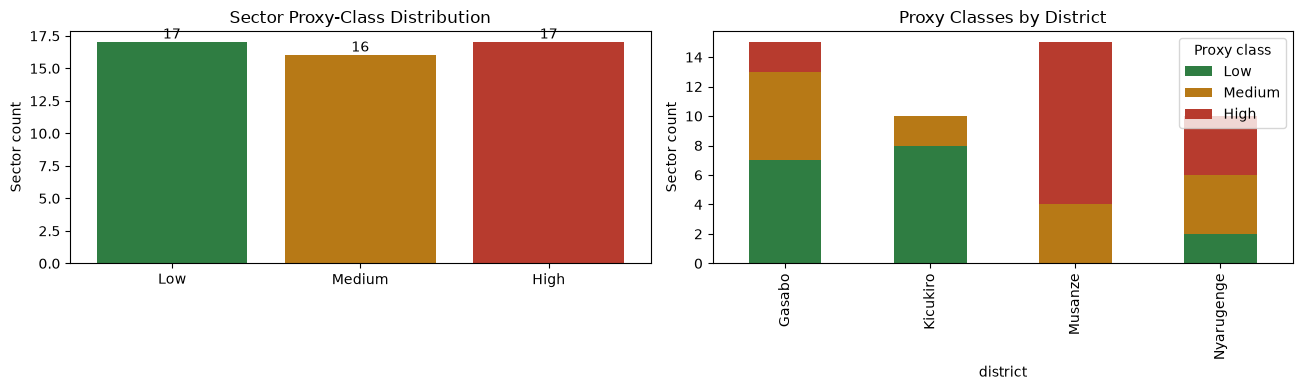

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(sector_class_counts.index, sector_class_counts.values, color=['#2f7d42', '#b77916', '#b73b2e'])
axes[0].set_title('Sector Proxy-Class Distribution')
axes[0].set_ylabel('Sector count')
for i, value in enumerate(sector_class_counts.values):
    axes[0].text(i, value + 0.3, str(value), ha='center')

district_class_counts.plot(kind='bar', stacked=True, ax=axes[1], color=['#2f7d42', '#b77916', '#b73b2e'])
axes[1].set_title('Proxy Classes by District')
axes[1].set_ylabel('Sector count')
axes[1].legend(title='Proxy class')
plt.tight_layout()
plt.show()

## 3. Train and evaluate the models

Every fold holds out one complete district. For the x10 table, this also keeps all subunits from the same sector on the same side of the split, because each sector belongs to only one district.

In [5]:
models = workflow.make_models()
all_oof, all_folds, all_performance, all_importance, all_reports, fitted_models = [], [], [], [], [], {}

for model_name, model in models.items():
    print(f'Evaluating {model_name} with leave-one-district-out validation...')
    oof, fold_metrics, overall = workflow.evaluate_model(model_name, model, data, selected_features)
    fitted_full = model.fit(data[selected_features], data['proxy_class'])
    importance = workflow.feature_importance(model_name, fitted_full, selected_features)
    report = pd.DataFrame(
        classification_report(
            oof['proxy_class'],
            oof['predicted_proxy_class'],
            labels=workflow.CLASS_ORDER,
            output_dict=True,
            zero_division=0,
        )
    ).transpose().reset_index(names='metric_or_class')
    report.insert(0, 'model', model_name)

    all_oof.append(oof)
    all_folds.append(fold_metrics)
    all_performance.append(overall)
    all_importance.append(importance)
    all_reports.append(report)
    fitted_models[model_name] = fitted_full

oof_predictions = pd.concat(all_oof, ignore_index=True)
district_fold_performance = pd.concat(all_folds, ignore_index=True)
model_performance = pd.concat(all_performance, ignore_index=True)
feature_importance = pd.concat(all_importance, ignore_index=True)
classification_reports = pd.concat(all_reports, ignore_index=True)
display(model_performance)

Evaluating random_forest with leave-one-district-out validation...


/Users/kellia.umuhire/Documents/capstone/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/kellia.umuhire/Documents/capstone/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Evaluating catboost with leave-one-district-out validation...


/Users/kellia.umuhire/Documents/capstone/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/kellia.umuhire/Documents/capstone/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,model,held_out_district,test_row_count,accuracy,balanced_accuracy,macro_f1,macro_precision,macro_recall
0,random_forest,all_oof,500,0.616,0.611887,0.607070,0.632327,0.611887
1,catboost,all_oof,500,0.430,0.431373,0.374659,0.485173,0.431373


,model,held_out_district,test_row_count,accuracy,balanced_accuracy,macro_f1,macro_precision,macro_recall
4,catboost,Gasabo,150,0.660000,0.546032,0.560611,0.759140,0.546032
5,catboost,Kicukiro,100,0.450000,0.318750,0.232421,0.266734,0.212500
6,catboost,Musanze,150,0.126667,0.165909,0.130741,0.410853,0.110606
7,catboost,Nyarugenge,100,0.520000,0.583333,0.436059,0.348188,0.583333
0,random_forest,Gasabo,150,0.606667,0.468254,0.451044,0.753523,0.468254
1,random_forest,Kicukiro,100,0.620000,0.387500,0.255144,0.252033,0.258333
2,random_forest,Musanze,150,0.706667,0.513636,0.352363,0.545355,0.342424
3,random_forest,Nyarugenge,100,0.490000,0.550000,0.411134,0.328283,0.550000


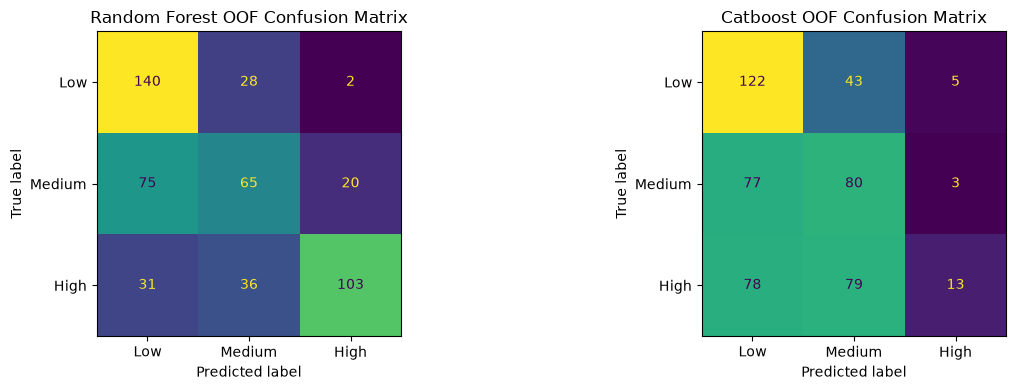

In [6]:
display(district_fold_performance.sort_values(['model', 'held_out_district']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for axis, model_name in zip(axes, ['random_forest', 'catboost']):
    subset = oof_predictions[oof_predictions['model'].eq(model_name)]
    matrix = confusion_matrix(subset['proxy_class'], subset['predicted_proxy_class'], labels=workflow.CLASS_ORDER)
    ConfusionMatrixDisplay(matrix, display_labels=workflow.CLASS_ORDER).plot(ax=axis, colorbar=False)
    axis.set_title(model_name.replace('_', ' ').title() + ' OOF Confusion Matrix')
plt.tight_layout()
plt.show()

## 4. Feature importance and sector assessments

Importance is descriptive, not causal. The consensus assessment averages the two models' out-of-fold probability estimates, so every sector is assessed by models that did not train on its district.

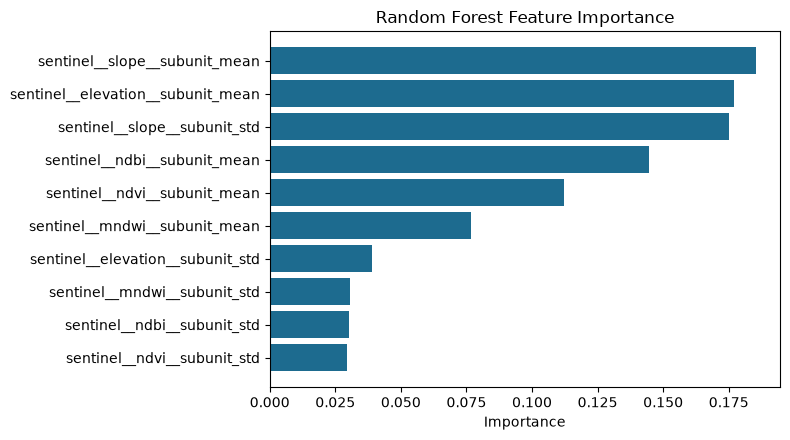

,model,feature,importance
0,random_forest,sentinel__slope__subunit_mean,0.185276
1,random_forest,sentinel__elevation__subunit_mean,0.176990
2,random_forest,sentinel__slope__subunit_std,0.174961
3,random_forest,sentinel__ndbi__subunit_mean,0.144432
4,random_forest,sentinel__ndvi__subunit_mean,0.112343
5,random_forest,sentinel__mndwi__subunit_mean,0.076588
6,random_forest,sentinel__elevation__subunit_std,0.039080
7,random_forest,sentinel__mndwi__subunit_std,0.030647
8,random_forest,sentinel__ndbi__subunit_std,0.030059
9,random_forest,sentinel__ndvi__subunit_std,0.029623


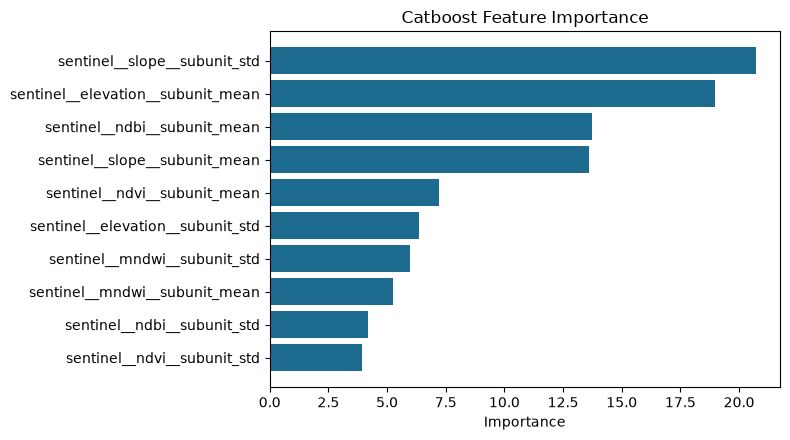

,model,feature,importance
10,catboost,sentinel__slope__subunit_std,20.709977
11,catboost,sentinel__elevation__subunit_mean,18.989705
12,catboost,sentinel__ndbi__subunit_mean,13.717757
13,catboost,sentinel__slope__subunit_mean,13.618294
14,catboost,sentinel__ndvi__subunit_mean,7.197602
15,catboost,sentinel__elevation__subunit_std,6.357805
16,catboost,sentinel__mndwi__subunit_std,5.998981
17,catboost,sentinel__mndwi__subunit_mean,5.268624
18,catboost,sentinel__ndbi__subunit_std,4.196522
19,catboost,sentinel__ndvi__subunit_std,3.944733


,sector_id,sector_name,district,proxy_class,proxy_score,proxy_rank,probability_low,probability_medium,probability_high,consensus_predicted_class,consensus_confidence,agreement_with_proxy_label
41,RWA.5.3.1_1,Gitega,Nyarugenge,High,0.524301,1,0.386526,0.531993,0.081480,Medium,0.531993,False
3,RWA.1.4.13_1,Remera,Musanze,High,0.523125,2,0.339734,0.308622,0.351643,High,0.351643,True
9,RWA.1.4.4_1,Gashaki,Musanze,High,0.517564,3,0.279706,0.297107,0.423187,High,0.423187,True
4,RWA.1.4.14_1,Rwaza,Musanze,High,0.509530,4,0.411822,0.287413,0.300765,Low,0.411822,False
23,RWA.5.1.3_1,Gikomero,Gasabo,High,0.490894,5,0.274608,0.404282,0.321109,Medium,0.404282,False
20,RWA.5.1.15_1,Rutunga,Gasabo,High,0.490130,6,0.286576,0.399174,0.314251,Medium,0.399174,False
8,RWA.1.4.3_1,Gacaca,Musanze,High,0.462987,7,0.345519,0.283247,0.371234,High,0.371234,True
5,RWA.1.4.15_1,Shingiro,Musanze,High,0.462571,8,0.415304,0.243211,0.341485,Low,0.415304,False
12,RWA.1.4.7_1,Kinigi,Musanze,High,0.441454,9,0.319748,0.336018,0.344233,High,0.344233,True
44,RWA.5.3.4_1,Kimisagara,Nyarugenge,High,0.440580,10,0.288730,0.634985,0.076284,Medium,0.634985,False


In [7]:
for model_name in ['random_forest', 'catboost']:
    subset = feature_importance[feature_importance['model'].eq(model_name)].sort_values('importance', ascending=True)
    plt.figure(figsize=(8, 4.5))
    plt.barh(subset['feature'], subset['importance'], color='#1d6b8f')
    plt.title(model_name.replace('_', ' ').title() + ' Feature Importance')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    display(subset.sort_values('importance', ascending=False))

probability_columns = [f'probability_{label.lower()}' for label in workflow.CLASS_ORDER]
sector_assessments = (
    oof_predictions.groupby(
        ['sector_id', 'sector_name', 'district', 'proxy_class', 'proxy_score', 'proxy_rank'], as_index=False
    )[probability_columns].mean()
)
sector_assessments['consensus_predicted_class'] = (
    sector_assessments[probability_columns].idxmax(axis=1).str.replace('probability_', '').str.title()
)
sector_assessments['consensus_confidence'] = sector_assessments[probability_columns].max(axis=1)
sector_assessments['agreement_with_proxy_label'] = sector_assessments['consensus_predicted_class'].eq(sector_assessments['proxy_class'])
display(sector_assessments.sort_values('proxy_rank'))

## 5. Save reproducible outputs

This writes the notebook-run metrics, out-of-fold predictions, feature importance, consensus assessments, and fitted models to the same project locations used by the command-line pipeline.

In [8]:
workflow.write_csv(training_view, OUTPUT_DIR / 'training_dataset.csv')
workflow.write_csv(feature_summary, OUTPUT_DIR / 'feature_summary.csv')
workflow.write_csv(district_class_counts.reset_index(), OUTPUT_DIR / 'district_class_distribution.csv')
workflow.write_csv(model_performance, OUTPUT_DIR / 'model_performance.csv')
workflow.write_csv(district_fold_performance, OUTPUT_DIR / 'district_fold_performance.csv')
workflow.write_csv(oof_predictions, OUTPUT_DIR / 'out_of_fold_predictions.csv')
workflow.write_csv(feature_importance, OUTPUT_DIR / 'feature_importance.csv')
workflow.write_csv(classification_reports, OUTPUT_DIR / 'classification_report.csv')
workflow.write_csv(sector_assessments.sort_values('proxy_rank'), OUTPUT_DIR / 'sector_model_assessments.csv')

for model_name, fitted_model in fitted_models.items():
    joblib.dump(
        {
            'model': fitted_model,
            'feature_columns': selected_features,
            'target': 'proxy_class',
            'training_unit': training_unit,
            'training_row_count': len(data),
            'independent_sector_count': int(data['sector_id'].nunique()),
            'evaluation': 'leave_one_district_out',
            'caveat': 'Proxy-label pilot. Do not interpret as validated Ubudehe prediction.',
        },
        MODEL_DIR / f'sector_proxy_{model_name}.joblib',
    )

print(f'Saved outputs to: {OUTPUT_DIR}')
print(f'Saved models to: {MODEL_DIR}')

Saved outputs to: /Users/kellia.umuhire/Documents/capstone/data/model_outputs
Saved models to: /Users/kellia.umuhire/Documents/capstone/models


## Interpretation guardrails

- The x10 table has more training rows, but still only 50 independent sector labels.
- All ten sector subunits inherit the same sector-level proxy label.
- The target is a census-informed proxy, not an official Ubudehe category.
- Model performance estimates have high uncertainty and should be treated as pilot results.
- More independent labels, or a finer label geography, are required before operational deployment.